**Group name**:  Group 10

**Created by**: May Sabai (017390438), Jerry Nguyen (016437330), Anusri Nagarajan (017743700)

**Last updated**: 11/29/2025

# Data Preparation
### Import necessary modules

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

### Load and Prepare the dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/project/data/renter_affordability_data - 2023.csv')
df.head(10)

Mounted at /content/drive


,RegionID,SizeRank,CityName,StateName,abb_StateName,Average Affordability,Population,Minimum Wage,Renter Income,State property tax,Median Income
0,394388,51,Birmingham,Alabama,AL,0.227831,196818.0,7.25,52619.50969,0.0036,44376.0
1,394698,114,Huntsville,Alabama,AL,0.195576,226228.0,7.25,55365.67706,0.0036,70778.0
2,394870,127,Mobile,Alabama,AL,0.258713,201920.0,7.25,47740.49434,0.0036,51090.0
3,394875,143,Montgomery,Alabama,AL,0.237828,196107.0,7.25,49439.14181,0.0036,55687.0
4,395171,188,Tuscaloosa,Alabama,AL,0.285725,113016.0,7.25,55426.68060,0.0036,48536.0
5,394519,203,Daphne,Alabama,AL,0.267592,30391.0,7.25,65028.83131,0.0036,86479.0
6,394351,253,Auburn,Alabama,AL,0.324518,82447.0,7.25,62293.66867,0.0036,77760.0
7,394523,276,Decatur,Alabama,AL,0.194370,57776.0,7.25,47251.34400,0.0036,59831.0
8,394598,292,Florence,Alabama,AL,0.196857,42442.0,7.25,40426.70243,0.0036,50396.0
9,394537,293,Dothan,Alabama,AL,0.242607,71317.0,7.25,46463.58399,0.0036,55052.0


In [ ]:
# check for empty cells
df.isnull().sum()

,0
RegionID,0
SizeRank,0
CityName,0
StateName,0
abb_StateName,0
Average Affordability,10
Population,9
Minimum Wage,0
Renter Income,10
State property tax,0


In [ ]:
# Drop rows with NA values
df = df.dropna(subset=['Median Income', 'Renter Income', 'Population', 'Average Affordability'])

# Split into Train and Test Data

In [ ]:
X = df.drop("Average Affordability", axis=1)
y = df["Average Affordability"]

In [ ]:
# 1 = Affordable (<=0.3), 0 = Unaffordable (>0.3)
y_binary = (y <= 0.3).astype(int)

In [ ]:
## Split dataset into training set and test set
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=1)
for train_index, test_index in split.split(X, y_binary):
    X_train = X.iloc[train_index]
    X_test = X.iloc[test_index]
    y_train = y_binary.iloc[train_index]
    y_test = y_binary.iloc[test_index]

# Preprocess the Data
Instead of replacing the NA values with median values, we remove them. Each row represents a different city. By replacing with median value, the final result would not be reliable.



Our dataset also do not have any text/ categorical information, such as weather, geographical location, or job opportunities that is helpful in categorizing rent affordability.

### Feature Engineering

In [ ]:
def affordability_feature_engineering(df):
    """
    Create new features from existing rent affordability data
    """
    df_fe = df.copy()

    # Col indices for calculations
    population_idx = df_fe.columns.get_loc("Population")
    wage_idx = df_fe.columns.get_loc("Minimum Wage")
    renter_income_idx = df_fe.columns.get_loc("Renter Income")
    property_tax_idx = df_fe.columns.get_loc("State property tax")
    median_income_idx = df_fe.columns.get_loc("Median Income")

    # Annual income based on minimum wage
    annual_min_wage = df_fe['Minimum Wage'] * 40 * 52  # 40 hrs/week, 52 weeks/year
    df_fe['min_wage_to_median_ratio'] = annual_min_wage / df_fe['Median Income']

    # Property tax burden related to median income
    df_fe['property_tax_burden'] = df_fe['State property tax'] * df_fe['Median Income']

    # Renter and Median income gap
    df_fe['renter_income_gap'] = df_fe['Median Income'] - df_fe['Renter Income']

    # Renter income percentage (relative disadvantage)
    df_fe['renter_income_percentage'] = df_fe['Renter Income'] / df_fe['Median Income']

    # Population categories
    df_fe['population_category'] = pd.cut(df_fe['Population'],
                                          bins=[0, 50000, 100000, 200000, np.inf],
                                          labels=['Small', 'Medium', 'Large', 'Very Large'])

    # Income level categories
    df_fe['income_level'] = pd.cut(df_fe['Median Income'],
                                   bins=[0, 40000, 60000, 80000, np.inf],
                                   labels=['Low', 'Medium', 'High', 'Very High'])

    return df_fe

In [ ]:
# Feature engineering
X_train_fe = affordability_feature_engineering(X_train)
X_test_fe = affordability_feature_engineering(X_test)

In [ ]:
### Drop redundant column
redunant_features = ['RegionID', 'SizeRank', 'CityName', 'StateName', 'abb_StateName',
                     'Minimum Wage', 'State property tax']
X_train_fe = X_train_fe.drop(columns=redunant_features)
X_test_fe = X_test_fe.drop(columns=redunant_features)

In [ ]:
X_train_fe.head()

,Population,Renter Income,Median Income,min_wage_to_median_ratio,property_tax_burden,renter_income_gap,renter_income_percentage,population_category,income_level
297,192606.0,77675.80427,66772.0,0.404960,701.1060,-10903.80427,1.163299,Large,High
120,270408.0,44055.34183,60293.0,0.250112,464.2561,16237.65817,0.730688,Very Large,High
303,38163.0,82803.16580,96715.0,0.155922,454.5605,13911.83420,0.856156,Small,Very High
355,45047.0,73921.75095,69829.0,0.357445,537.6833,-4092.75095,1.058611,Small,High
385,49614.0,42051.68461,62953.0,0.239544,786.9125,20901.31539,0.667985,Small,High


### Encode Categorical variable

In [ ]:
# One-hot encoding for categorical variables
def encode(df):
    # Get list of numerical columns before encoding
    numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

    # One-hot encode
    encode = pd.get_dummies(df,
                           columns=['population_category', 'income_level'],
                           drop_first=True)

    # Convert only NEW encoded columns to int
    val_cols = [col for col in encode.columns if col not in numerical_cols]
    encode[val_cols] = encode[val_cols].astype(int)

    # Round numerical columns to 2 decimal places
    encode[numerical_cols] = encode[numerical_cols].round(2)

    return encode

# One-hot encode
X_train_fe_enc = encode(X_train_fe)
X_test_fe_enc = encode(X_test_fe)

### Feature Scaling

In [ ]:
# Separate numerical cols
X_train_fe_enc_num = X_train_fe_enc.select_dtypes(include=['int64', 'float64'])
X_test_fe_enc_num = X_test_fe_enc.select_dtypes(include=['int64', 'float64'])

# Standardize numerical cols
scaler = StandardScaler()

## Fit the scaler only on training data, transform
X_train_fe_scaled = scaler.fit_transform(X_train_fe_enc_num)

## Transform test data using scaler
X_test_fe_scaled = scaler.transform(X_test_fe_enc_num)

In [ ]:
X_train_fe_scaled

array([[-0.06335502,  1.03627765,  0.27862172, ..., -0.87548105,
         1.11888712, -0.31089271],
       [ 0.06429938, -0.88599947, -0.13698051, ..., -0.87548105,
         1.11888712, -0.31089271],
       [-0.31675889,  1.3294392 ,  2.19934676, ..., -0.87548105,
        -0.8937452 ,  3.21654377],
       ...,
       [-0.33967539, -0.42733224, -0.81699274, ...,  1.14222918,
        -0.8937452 , -0.31089271],
       [-0.32035872,  0.74726878, -0.083611  , ..., -0.87548105,
         1.11888712, -0.31089271],
       [-0.32862651, -1.34907152, -1.25600827, ...,  1.14222918,
        -0.8937452 , -0.31089271]])

In [ ]:
y_train

,Average Affordability
297,1
120,1
303,0
355,1
385,1
...,...
335,1
228,1
230,1
82,0


# Select Supervised Machine Learning Models

Model Type: **Classification** (classify if rent affordability is greater than or less than/equal to 30%). Class 1 is considered affordable (less than or equal to 30%).
Class 0 is considered unaffordable (greater than 30%).

**Variables**
*   **Target Variable**: Average Affordability
*   **Features**
    * Population
    * Renter Income: Average income of renters
    * Median Income: Median household income
    * min_wage_to_median_ratio: How adequate minimum wage is compared to median income
    * property_tax_burden: Absolute property tax cost (tax rate x median income)
    * renter_income_gap: How much renters earn compared to median income
    * renter_income_percentage: Renter income as a percentage of median income




# Logistic Regression Model

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

- Initialize the Logistic Regression model
- set up StratifiedKFold for cross-validation
- perform the cross-validation
- print the mean and standard deviation of the evaluation metrics



In [ ]:
model = LogisticRegression(random_state=42, solver='liblinear')
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = ['accuracy', 'precision', 'recall', 'f1']
cv_results = cross_validate(model, X_train_fe_scaled, y_train, cv=kf, scoring=scoring)

print("Cross-validation results:")
for score_name in scoring:
    mean_score = cv_results[f'test_{score_name}'].mean()
    std_score = cv_results[f'test_{score_name}'].std()
    print(f"  Mean {score_name}: {mean_score:.4f} (Std: {std_score:.4f})")

Cross-validation results:
  Mean accuracy: 0.8814 (Std: 0.0322)
  Mean precision: 0.9023 (Std: 0.0173)
  Mean recall: 0.9689 (Std: 0.0261)
  Mean f1: 0.9343 (Std: 0.0180)


Now, we train the Logistic Regression model on the entire training dataset, make predictions on the test set, and evaluate its performance.



Test Set Evaluation:
              precision    recall  f1-score   support

           0       1.00      0.78      0.88         9
           1       0.97      1.00      0.98        65

    accuracy                           0.97        74
   macro avg       0.99      0.89      0.93        74
weighted avg       0.97      0.97      0.97        74



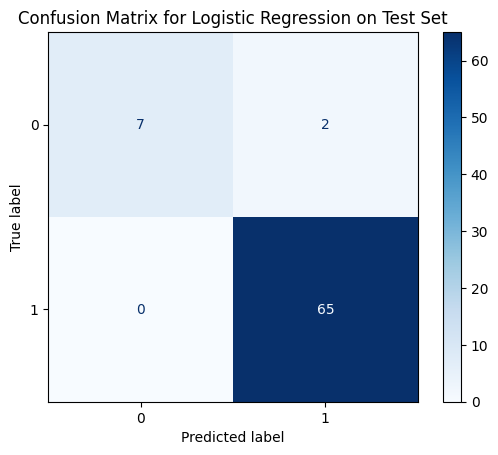

In [ ]:
model.fit(X_train_fe_scaled, y_train)
y_pred = model.predict(X_test_fe_scaled)

print("\nTest Set Evaluation:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for Logistic Regression on Test Set")
plt.show()

## Summary:

- With 5-fold stratified split cross-validation, the model achieved a mean accuracy of 0.8814 (Std: 0.0322), mean precision of 0.9023 (Std: 0.0173), mean recall of 0.9689 (Std: 0.0261), and mean F1-score of 0.9343 (Std: 0.0180).

- On the test set, the model achieved an overall accuracy of 0.97.

- 5-fold stratified cross-validation on the training data had mean accuracy of 0.8814, mean precision of 0.9023, mean recall of 0.9689, and mean F1-score of 0.9343. The low standard deviations show that there was consistency across the folds.
- On the test set, the model showed strong generalization, having an overall accuracy of 0.97.
- High precision (1.00) for class 0 but lower recall (0.78). This means the model rarely class 1 as class 0, but missed identifying some actual class 0 instances.
*   For class 1, the model achieved perfect recall (1.00) and high precision (0.97), showing that it correctly identified these class instances and had very few false positives
*   Most of the misclassifications were false negatives for the minority class


# Random Forest Classifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Initialize Random Forest Classifier
rf_model = RandomForestClassifier(random_state=42)

# Train model
rf_model.fit(X_train_fe_scaled, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# StratifiedKFold for cross-validation
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define scoring metrics
scoring = ['accuracy', 'precision', 'recall', 'f1']

# Perform cross-validation
cv_results_rf = cross_validate(rf_model, X_train_fe_scaled, y_train, cv=kf, scoring=scoring)

print("Cross-validation results for Random Forest:")
for score_name in scoring:
    mean_score = cv_results_rf[f'test_{score_name}'].mean()
    std_score = cv_results_rf[f'test_{score_name}'].std()
    print(f"  Mean {score_name}: {mean_score:.4f} (Std: {std_score:.4f})")

Cross-validation results for Random Forest:
  Mean accuracy: 0.8814 (Std: 0.0356)
  Mean precision: 0.9026 (Std: 0.0154)
  Mean recall: 0.9691 (Std: 0.0449)
  Mean f1: 0.9340 (Std: 0.0212)



Test Set Evaluation for Random Forest:
              precision    recall  f1-score   support

           0       0.88      0.78      0.82         9
           1       0.97      0.98      0.98        65

    accuracy                           0.96        74
   macro avg       0.92      0.88      0.90        74
weighted avg       0.96      0.96      0.96        74



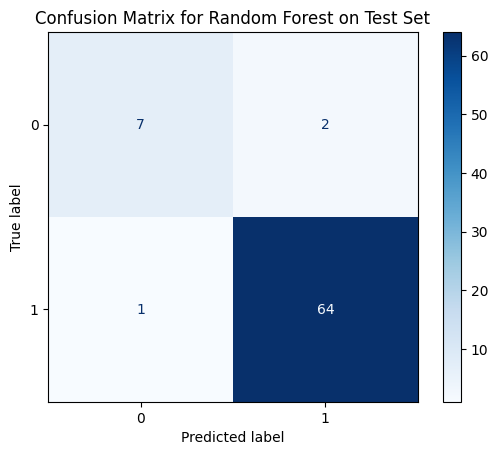

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test_fe_scaled)

print("\nTest Set Evaluation for Random Forest:")
print(classification_report(y_test, y_pred_rf))

# confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=rf_model.classes_)
disp_rf.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for Random Forest on Test Set")
plt.show()

### Summary for Random Forest Classifier:

- With 5-fold stratified cross-validation on the training data, the Random Forest model achieved a mean accuracy of 0.8814 (Std: 0.0356), mean precision of 0.9026 (Std: 0.0154), mean recall of 0.9691 (Std: 0.0449), and mean F1-score of 0.9340 (Std: 0.0212). This shows consistent performance across different folds.

- On the test set, the model showed overall accuracy of 0.96.

- For class 0 (Unaffordable), the model achieved a precision of 0.88 and a recall of 0.78. This shows the model is precise when predicting unaffordable cases but still misses some actual unaffordable instances.

- For class 1 (Affordable), the model achieved precision 0.97 and recall 0.98. This shows the model is good at identifying affordable cases and has very few false positives and false negatives.

- Compared to the Logistic Regression model, the Random Forest Classifier showed slightly better overall accuracy on the test set (0.96 vs 0.97).

# K-Nearest Neighbors

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# Initialize KNN with n_neighbors=5
knn_model = KNeighborsClassifier(n_neighbors=5)

# Train the model
knn_model.fit(X_train_fe_scaled, y_train)

KNeighborsClassifier()

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_validate

# StratifiedKFold for cross-validation
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define scoring metrics
scoring = ['accuracy', 'precision', 'recall', 'f1']

# Perform cross-validation
cv_results_knn = cross_validate(knn_model, X_train_fe_scaled, y_train, cv=kf, scoring=scoring)

print("Cross-validation results for K-Nearest Neighbors:")
for score_name in scoring:
    mean_score = cv_results_knn[f'test_{score_name}'].mean()
    std_score = cv_results_knn[f'test_{score_name}'].std()
    print(f"  Mean {score_name}: {mean_score:.4f} (Std: {std_score:.4f})")

Cross-validation results for K-Nearest Neighbors:
  Mean accuracy: 0.8678 (Std: 0.0392)
  Mean precision: 0.8977 (Std: 0.0193)
  Mean recall: 0.9570 (Std: 0.0315)
  Mean f1: 0.9263 (Std: 0.0230)



Test Set Evaluation for K-Nearest Neighbors:
              precision    recall  f1-score   support

           0       1.00      0.33      0.50         9
           1       0.92      1.00      0.96        65

    accuracy                           0.92        74
   macro avg       0.96      0.67      0.73        74
weighted avg       0.93      0.92      0.90        74



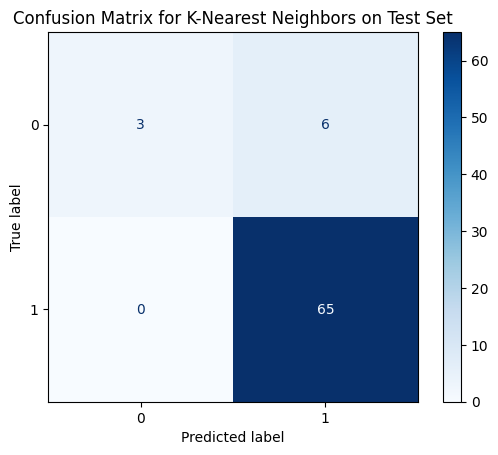

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Make predictions on the test set
y_pred_knn = knn_model.predict(X_test_fe_scaled)

print("\nTest Set Evaluation for K-Nearest Neighbors:")
print(classification_report(y_test, y_pred_knn))

# confusion matrix
cm_knn = confusion_matrix(y_test, y_pred_knn)
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=knn_model.classes_)
disp_knn.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for K-Nearest Neighbors on Test Set")
plt.show()

## Summary:

- KNN model was initialized with `n_neighbors=5`
- During 5-fold stratified cross-validation, the model achieved mean accuracy of 0.8678 (Std: 0.0392), mean precision of 0.8977 (Std: 0.0193), mean recall of 0.9570 (Std: 0.0315), and mean F1-score of 0.9263 (Std: 0.0230).
- On the test set, the KNN model showed an overall accuracy of 0.92.
- For class 0, the model had a precision of 1.00, recall of 0.33, and F1-score of 0.50.
- For class 1, it had a precision of 0.92, recall of 1.00, and F1-score of 0.96.
- The macro average F1-score was 0.73, and the weighted average F1-score was 0.90.


## Model Comparison

In [ ]:
import pandas as pd
from sklearn.metrics import classification_report

# logistic regression results
lr_cv_accuracy = cv_results['test_accuracy'].mean()
lr_cv_precision = cv_results['test_precision'].mean()
lr_cv_recall = cv_results['test_recall'].mean()
lr_cv_f1 = cv_results['test_f1'].mean()

# test set results
report_lr_test = classification_report(y_test, y_pred, output_dict=True)
lr_test_accuracy = report_lr_test['accuracy']
lr_test_precision_macro = report_lr_test['macro avg']['precision']
lr_test_recall_macro = report_lr_test['macro avg']['recall']
lr_test_f1_macro = report_lr_test['macro avg']['f1-score']
lr_test_precision_class0 = report_lr_test['0']['precision']
lr_test_recall_class0 = report_lr_test['0']['recall']
lr_test_f1_class0 = report_lr_test['0']['f1-score']
lr_test_precision_class1 = report_lr_test['1']['precision']
lr_test_recall_class1 = report_lr_test['1']['recall']
lr_test_f1_class1 = report_lr_test['1']['f1-score']

# random forest results
rf_cv_accuracy = cv_results_rf['test_accuracy'].mean()
rf_cv_precision = cv_results_rf['test_precision'].mean()
rf_cv_recall = cv_results_rf['test_recall'].mean()
rf_cv_f1 = cv_results_rf['test_f1'].mean()

# test set results
report_rf_test = classification_report(y_test, y_pred_rf, output_dict=True)
rf_test_accuracy = report_rf_test['accuracy']
rf_test_precision_macro = report_rf_test['macro avg']['precision']
rf_test_recall_macro = report_rf_test['macro avg']['recall']
rf_test_f1_macro = report_rf_test['macro avg']['f1-score']
rf_test_precision_class0 = report_rf_test['0']['precision']
rf_test_recall_class0 = report_rf_test['0']['recall']
rf_test_f1_class0 = report_rf_test['0']['f1-score']
rf_test_precision_class1 = report_rf_test['1']['precision']
rf_test_recall_class1 = report_rf_test['1']['recall']
rf_test_f1_class1 = report_rf_test['1']['f1-score']

#KNN metrics
knn_cv_accuracy = cv_results_knn['test_accuracy'].mean()
knn_cv_precision = cv_results_knn['test_precision'].mean()
knn_cv_recall = cv_results_knn['test_recall'].mean()
knn_cv_f1 = cv_results_knn['test_f1'].mean()

# Test set results
report_knn_test = classification_report(y_test, y_pred_knn, output_dict=True)
knn_test_accuracy = report_knn_test['accuracy']
knn_test_precision_macro = report_knn_test['macro avg']['precision']
knn_test_recall_macro = report_knn_test['macro avg']['recall']
knn_test_f1_macro = report_knn_test['macro avg']['f1-score']
knn_test_precision_class0 = report_knn_test['0']['precision']
knn_test_recall_class0 = report_knn_test['0']['recall']
knn_test_f1_class0 = report_knn_test['0']['f1-score']
knn_test_precision_class1 = report_knn_test['1']['precision']
knn_test_recall_class1 = report_knn_test['1']['recall']
knn_test_f1_class1 = report_knn_test['1']['f1-score']

comparison_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'K-Nearest Neighbors'],
    # cross-validation metrics
    'CV Mean Accuracy': [lr_cv_accuracy, rf_cv_accuracy, knn_cv_accuracy],
    'CV Mean Precision': [lr_cv_precision, rf_cv_precision, knn_cv_precision],
    'CV Mean Recall': [lr_cv_recall, rf_cv_recall, knn_cv_recall],
    'CV Mean F1-Score': [lr_cv_f1, rf_cv_f1, knn_cv_f1],
    # Test set metrics
    'Test Accuracy': [lr_test_accuracy, rf_test_accuracy, knn_test_accuracy],
    'Test Macro Precision': [lr_test_precision_macro, rf_test_precision_macro, knn_test_precision_macro],
    'Test Macro Recall': [lr_test_recall_macro, rf_test_recall_macro, knn_test_recall_macro],
    'Test Macro F1-Score': [lr_test_f1_macro, rf_test_f1_macro, knn_test_f1_macro],
    # Test Set unaffordable class metrics
    'Test Precision (Class 0)': [lr_test_precision_class0, rf_test_precision_class0, knn_test_precision_class0],
    'Test Recall (Class 0)': [lr_test_recall_class0, rf_test_recall_class0, knn_test_recall_class0],
    'Test F1-Score (Class 0)': [lr_test_f1_class0, rf_test_f1_class0, knn_test_f1_class0],
    # Test set affordable class metrics
    'Test Precision (Class 1)': [lr_test_precision_class1, rf_test_precision_class1, knn_test_precision_class1],
    'Test Recall (Class 1)': [lr_test_recall_class1, rf_test_recall_class1, knn_test_recall_class1],
    'Test F1-Score (Class 1)': [lr_test_f1_class1, rf_test_f1_class1, knn_test_f1_class1]
})

display(comparison_df.round(4))


,Model,CV Mean Accuracy,CV Mean Precision,CV Mean Recall,CV Mean F1-Score,Test Accuracy,Test Macro Precision,Test Macro Recall,Test Macro F1-Score,Test Precision (Class 0),Test Recall (Class 0),Test F1-Score (Class 0),Test Precision (Class 1),Test Recall (Class 1),Test F1-Score (Class 1)
0,Logistic Regression,0.8814,0.9023,0.9689,0.9343,0.9730,0.9851,0.8889,0.9299,1.000,0.7778,0.8750,0.9701,1.0000,0.9848
1,Random Forest,0.8814,0.9026,0.9691,0.9340,0.9595,0.9223,0.8812,0.9003,0.875,0.7778,0.8235,0.9697,0.9846,0.9771
2,K-Nearest Neighbors,0.8678,0.8977,0.9570,0.9263,0.9189,0.9577,0.6667,0.7279,1.000,0.3333,0.5000,0.9155,1.0000,0.9559


## ROC and Precision-Recall Curves




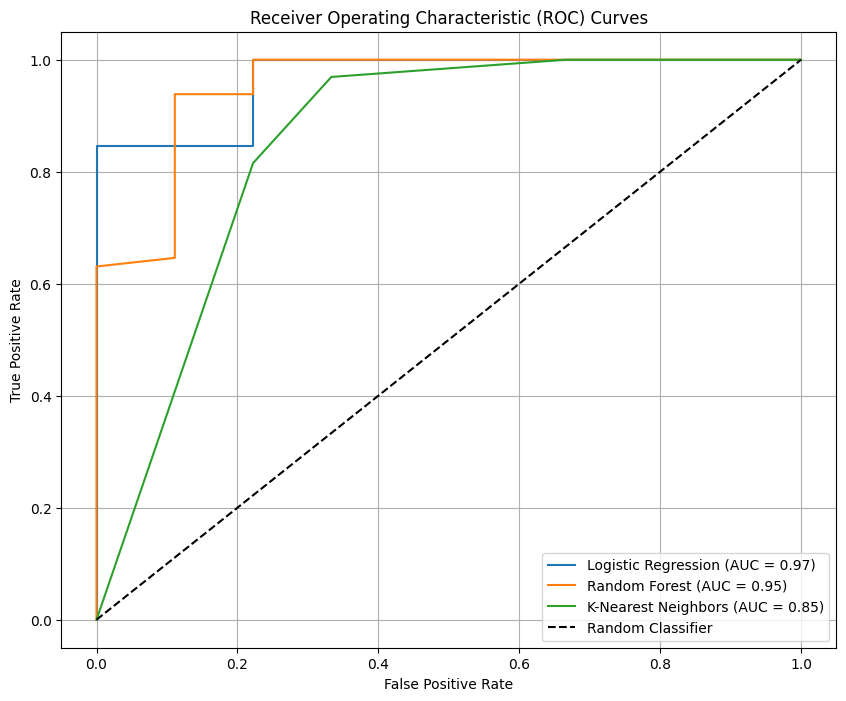

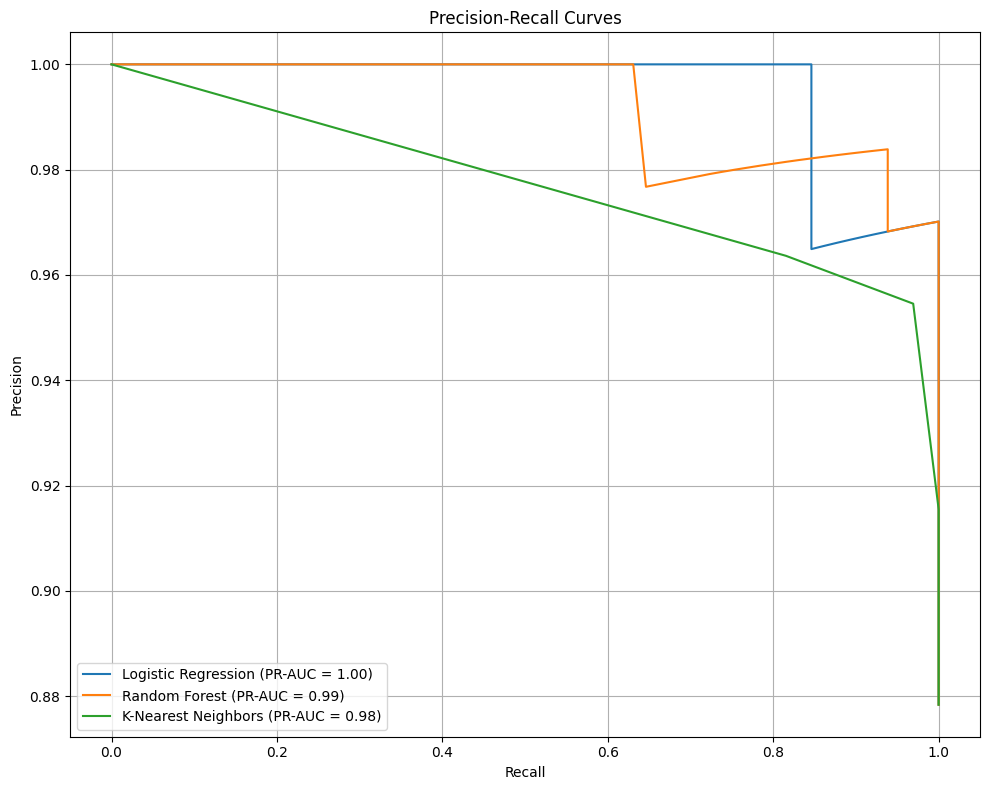

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, auc
import matplotlib.pyplot as plt

# Initialize figures for the curves
fig_roc, ax_roc = plt.subplots(figsize=(10, 8))
fig_pr, ax_pr = plt.subplots(figsize=(10, 8))

models = {
    'Logistic Regression': model,
    'Random Forest': rf_model,
    'K-Nearest Neighbors': knn_model
}

# Loop through models
for name, current_model in models.items():
    # Get predicted probabilities
    if hasattr(current_model, 'predict_proba'):
        y_pred_proba = current_model.predict_proba(X_test_fe_scaled)[:, 1]
    else:
        print(f"Warning: {name} does not have predict_proba. Skipping curve generation for this model.")
        continue

    # ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    ax_roc.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')

    # precision recall curve
    precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
    pr_auc = auc(recall, precision)
    ax_pr.plot(recall, precision, label=f'{name} (PR-AUC = {pr_auc:.2f})')

ax_roc.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
ax_roc.set_xlabel('False Positive Rate')
ax_roc.set_ylabel('True Positive Rate')
ax_roc.set_title('Receiver Operating Characteristic (ROC) Curves')
ax_roc.legend(loc='lower right')
ax_roc.grid(True)

ax_pr.set_xlabel('Recall')
ax_pr.set_ylabel('Precision')
ax_pr.set_title('Precision-Recall Curves')
ax_pr.legend(loc='lower left')
ax_pr.grid(True)

plt.tight_layout()
plt.show()

##Feature importance for Logistic Regression Model



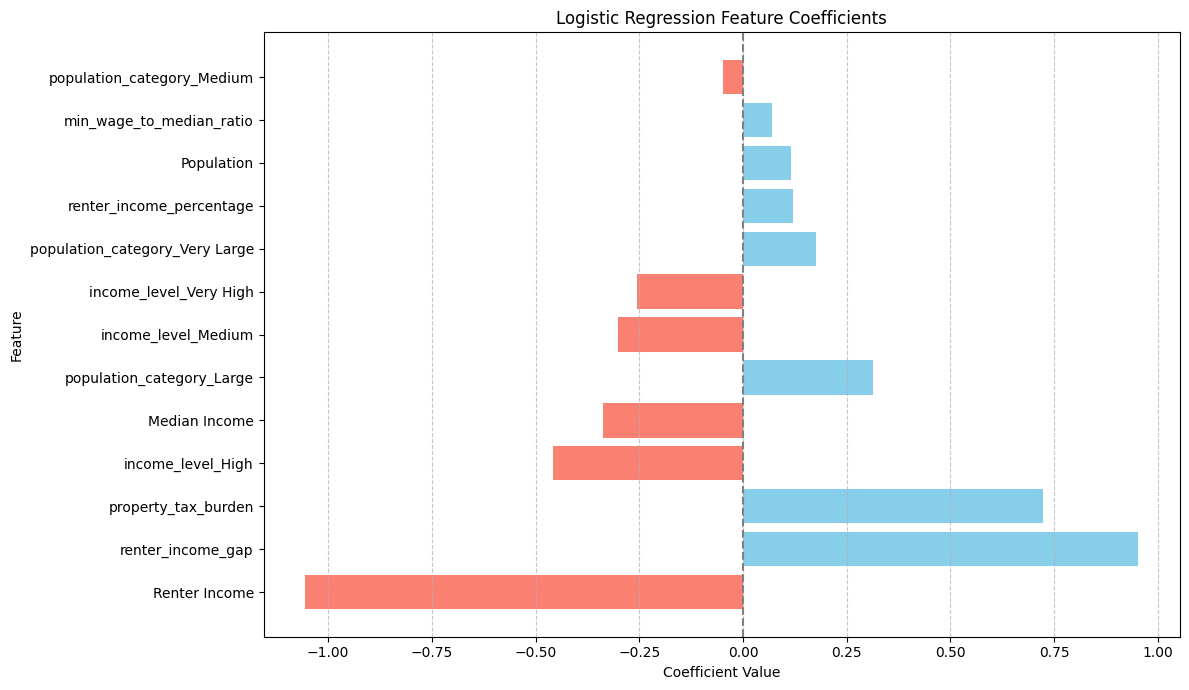

In [ ]:
feature_names = X_train_fe_enc_num.columns
coefficients = model.coef_[0]

# Create a DataFrame for better visualization
coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})
coef_df = coef_df.reindex(coef_df['Coefficient'].abs().sort_values(ascending=False).index)

plt.figure(figsize=(12, 7))
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=['skyblue' if c > 0 else 'salmon' for c in coef_df['Coefficient']])
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.title('Logistic Regression Feature Coefficients')
plt.axvline(x=0, color='grey', linestyle='--')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

##Feature importance for Random Forest Model



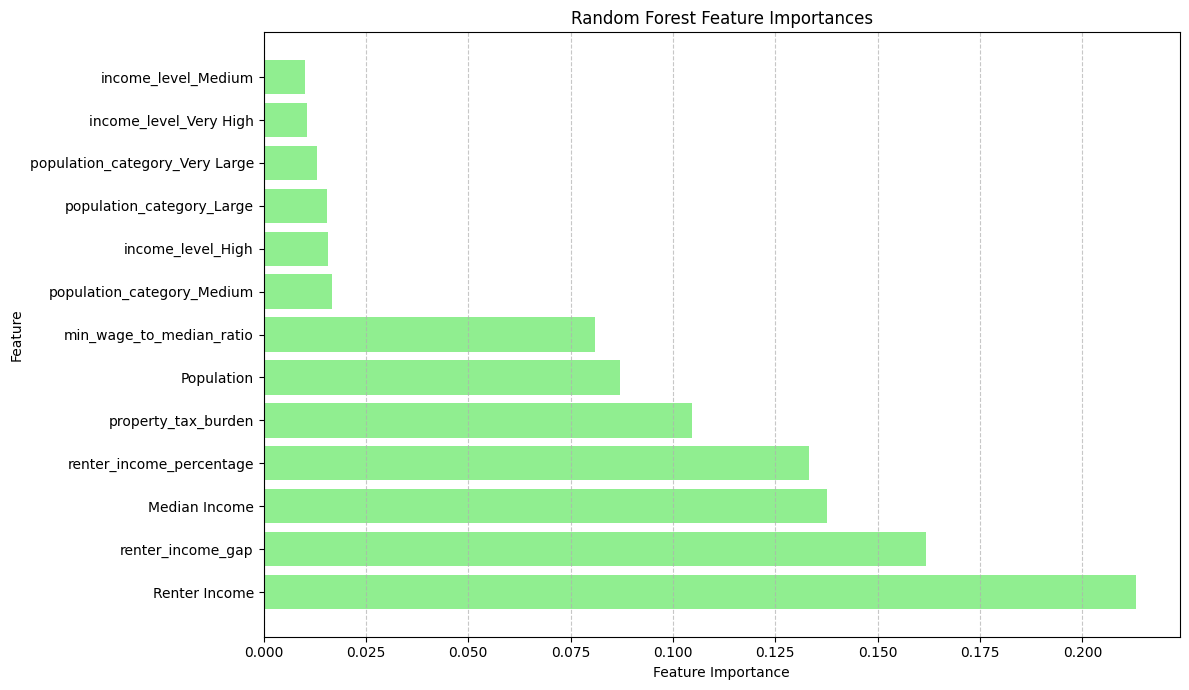

In [ ]:
feature_importances = rf_model.feature_importances_

# Create df for visualization
rf_feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})
rf_feature_importance_df = rf_feature_importance_df.reindex(rf_feature_importance_df['Importance'].abs().sort_values(ascending=False).index)

plt.figure(figsize=(12, 7))
plt.barh(rf_feature_importance_df['Feature'], rf_feature_importance_df['Importance'], color='lightgreen')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Random Forest Feature Importances')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Comparing the Models

*   **Cross-Validation Performance:**
    *   All three models show very similar mean cross-validation scores across accuracy, precision, recall, and F1-score. Logistic Regression and Random Forest have slightly higher mean scores compared to KNN, with Random Forest showing the best overall consistency (lowest standard deviations) in its CV results.

*   **Overall Test Set Performance (Accuracy & Macro Averages):**
    *   **Logistic Regression** achieved the highest overall Test Accuracy (0.97) and a strong Macro F1-Score (0.93).
    *   **Random Forest** followed closely with a Test Accuracy of 0.96 and a Macro F1-Score of 0.90.
    *   **K-Nearest Neighbors** had a Test Accuracy of 0.92 and the lowest Macro F1-Score of 0.73.

*   **Class 0 (Unaffordable) Performance (Minority Class):**
    *   **Logistic Regression** demonstrated perfect precision (1.00) for Class 0, meaning it never incorrectly classified a Class 1 as Class 0. However, its recall (0.78) was not perfect, indicating it missed some actual Class 0 instances.
    *   **Random Forest** had a precision of 0.88 and a recall of 0.78 for Class 0, showing a slightly lower precision than LR but the same recall.
    *   **K-Nearest Neighbors** also achieved perfect precision (1.00) for Class 0 but had significantly lower recall (0.33), meaning it missed a large number of actual Class 0 instances. This resulted in a very low F1-Score (0.50) for this class.

*   **Class 1 (Affordable) Performance (Majority Class):**
    *   All models performed exceptionally well on the majority class (Class 1). Logistic Regression and KNN both achieved perfect recall (1.00), while Random Forest was very close at 0.98. Precision for Class 1 was also very high across all models (0.92-0.97).

### Conclusion:

*   **Logistic Regression** appears to be the strongest performer overall, especially considering its high overall accuracy and its perfect precision for the minority class, despite a slightly lower recall for Class 0. It strikes a good balance for this dataset.
*   **Random Forest** is a close second, offering strong performance and consistency.
*   **K-Nearest Neighbors**, while strong on the majority class, significantly struggled with identifying the minority class (Class 0), as evidenced by its low recall, making it less suitable for scenarios where identifying 'Unaffordable' regions is critical. The low F1-score for Class 0 indicates it's not effectively identifying the minority class.

### ROC and Precision-Recall Curves:

*   **ROC Curves:** All three models (Logistic Regression, Random Forest, and K-Nearest Neighbors) show high AUC scores on the ROC curve, generally indicating good separation between the positive and negative classes. Logistic Regression and Random Forest appear to have slightly better overall performance across various thresholds compared to KNN.
*   **Precision-Recall Curves:** The Precision-Recall curves provide a more informative view, especially given the class imbalance (more affordable cases than unaffordable ones). All models maintain high precision and recall for the majority class (Affordable). However, for the minority class (Unaffordable), the performance differences become more apparent:
    *   **Logistic Regression:** Demonstrates a relatively strong Precision-Recall curve, maintaining good precision even at higher recall values. This aligns with its perfect precision for class 0 on the test set.
    *   **Random Forest:** Also shows a robust Precision-Recall curve, very similar to Logistic Regression, indicating good performance in identifying the minority class.
    *   **K-Nearest Neighbors:** The PR curve for KNN is noticeably lower, especially when trying to achieve higher recall. This confirms its struggle with the minority class, as highlighted by its low recall for Class 0 in the test set evaluations.

### Feature Importance:

*   **Logistic Regression Coefficients:**
    *   **Negative Coefficients:** `Renter Income`, `Median Income`, `min_wage_to_median_ratio`, and `income_level_High`, `income_level_Medium`, `income_level_Very High` have negative coefficients. This suggests that higher values in these features tend to make the model predict the 'unaffordable' class (Class 0, based on how the target was encoded, where 1 is affordable and 0 is unaffordable for y_binary = (y <= 0.3).astype(int)). Conversely, lower values would favor 'affordable'.
    *   **Positive Coefficients:** `renter_income_gap`, `property_tax_burden`, `renter_income_percentage`, `Population`, `population_category_Medium`, `population_category_Large`, `population_category_Very Large` have positive coefficients. This indicates that higher values in these features contribute to predicting the 'affordable' class (Class 1).
    *   **Most Influential Features:** The features with the largest absolute coefficients are `Renter Income`, `renter_income_gap`, and `property_tax_burden`, suggesting these are strong indicators for rent affordability in the Logistic Regression model.

*   **Random Forest Feature Importances:**
    *   The Random Forest model generally assigns high importance to similar features as Logistic Regression, but the ranking and relative importance might differ.
    *   `Renter Income`, `renter_income_gap`, `Median Income`, `renter_income_percentage`, and `property_tax_burden` are among the top features. This indicates that income-related metrics and the financial burden of property tax are consistently critical across different model types.
    *   Population-related features and minimum wage ratio also contribute, but generally with lower importance compared to the income and tax burden metrics.